# Aggregated Dependency Network
CODE FOR AGGREGATING DEPENDENCY NETWORK (UNDIRECTED-WEIGHTED VERSION) AT TRACTxTAXONOMY LEVEL

In [1]:
import pandas as pd
import networkx as nx
import numpy as np

In [2]:
data = pd.read_csv(
    'data/DEP_NET_UNDIRECT_14460_20190101_20191231_Tc24_Ts1.csv.gz',
    dtype={'GEOID_ORIGIN': str, 'GEOID_DESTINATION': str, 'ORIGIN': str, 'DESTINATION': str}
)
data = data[(data.N_UIDS_ORIGIN >= 50) & (data.N_UIDS_DESTINATION >= 50)]
data['TT_O'] = data.GEOID_ORIGIN.str[:11] + '_' + data.TAXONOMY_ORIGIN
data['TT_D'] = data.GEOID_DESTINATION.str[:11] + '_' + data.TAXONOMY_DESTINATION

# canonicalize the undirected pair on tract-tax
mask = data['TT_O'] <= data['TT_D']
data['A'] = np.where(mask, data['TT_O'], data['TT_D'])
data['B'] = np.where(mask, data['TT_D'], data['TT_O'])

# per-tract-tax visit totals from deduped POIs
visits = pd.concat([
    data[['ORIGIN', 'TT_O', 'N_VISITS_ORIGIN']].set_axis(['POI', 'TT', 'N_VISITS'], axis=1),
    data[['DESTINATION', 'TT_D', 'N_VISITS_DESTINATION']].set_axis(['POI', 'TT', 'N_VISITS'], axis=1),
]).drop_duplicates('POI').groupby('TT')['N_VISITS'].sum()

edges = (data.groupby(['A', 'B'], as_index=False)['N_COVISITS'].sum()
             .rename(columns={'A': 'ORIGIN', 'B': 'DESTINATION'}))
edges['N_VISITS_ORIGIN'] = edges['ORIGIN'].map(visits)
edges['N_VISITS_DESTINATION'] = edges['DESTINATION'].map(visits)
edges['DEP'] = edges['N_COVISITS'] / (edges['N_VISITS_ORIGIN'] * edges['N_VISITS_DESTINATION'])
edges = edges[['ORIGIN', 'DESTINATION', 'N_VISITS_ORIGIN', 'N_VISITS_DESTINATION', 'N_COVISITS', 'DEP']]

# drop self-loops
edges = edges[edges.ORIGIN != edges.DESTINATION]

# --- convert & report ---

G_agg = nx.from_pandas_edgelist(edges, source='ORIGIN', target='DESTINATION', edge_attr=True)

print(f'nodes: {G_agg.number_of_nodes()} | edges: {G_agg.number_of_edges()}')

nodes: 14566 | edges: 4885353


In [ ]:
import seaborn as sns

<Axes: xlabel='DEP', ylabel='Density'>

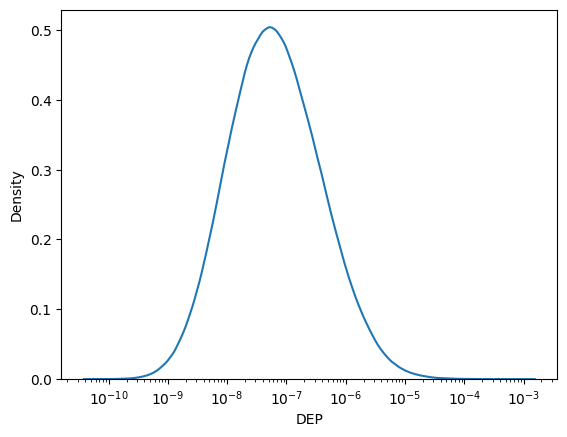

In [16]:
sns.kdeplot(data=edges, x='DEP', log_scale=(True, False))